<div style="background: linear-gradient(135deg, #0F172A, #1E3A8A, #2563EB); padding: 28px; border-radius: 18px; color: white; font-family: Arial, sans-serif;">

<center>

<img src="https://img.shields.io/badge/Kaggle-Notebook-20BEFF?style=for-the-badge&logo=kaggle&logoColor=white">
<img src="https://img.shields.io/badge/Machine%20Learning-Efficiency-22C55E?style=for-the-badge">
<img src="https://img.shields.io/badge/Radar%20Visualization-Performance-F59E0B?style=for-the-badge">

<h1 style="font-size: 34px; font-weight: 800; margin-top: 18px;">
Comparative Efficiency Profiling of Machine Learning Models
</h1>

<p style="font-size: 17px; line-height: 1.7; color: #E0F2FE; max-width: 950px;">
This notebook compares multiple machine learning models using radar-based visual analysis of inference time, 
per-sample latency, memory usage, and training time. The evaluation highlights computational efficiency, 
deployment suitability, and resource requirements across Extra Trees, XGBoost, Random Forest, CatBoost, 
KNN, Decision Tree, and MLP models.
</p>

</center>

</div>

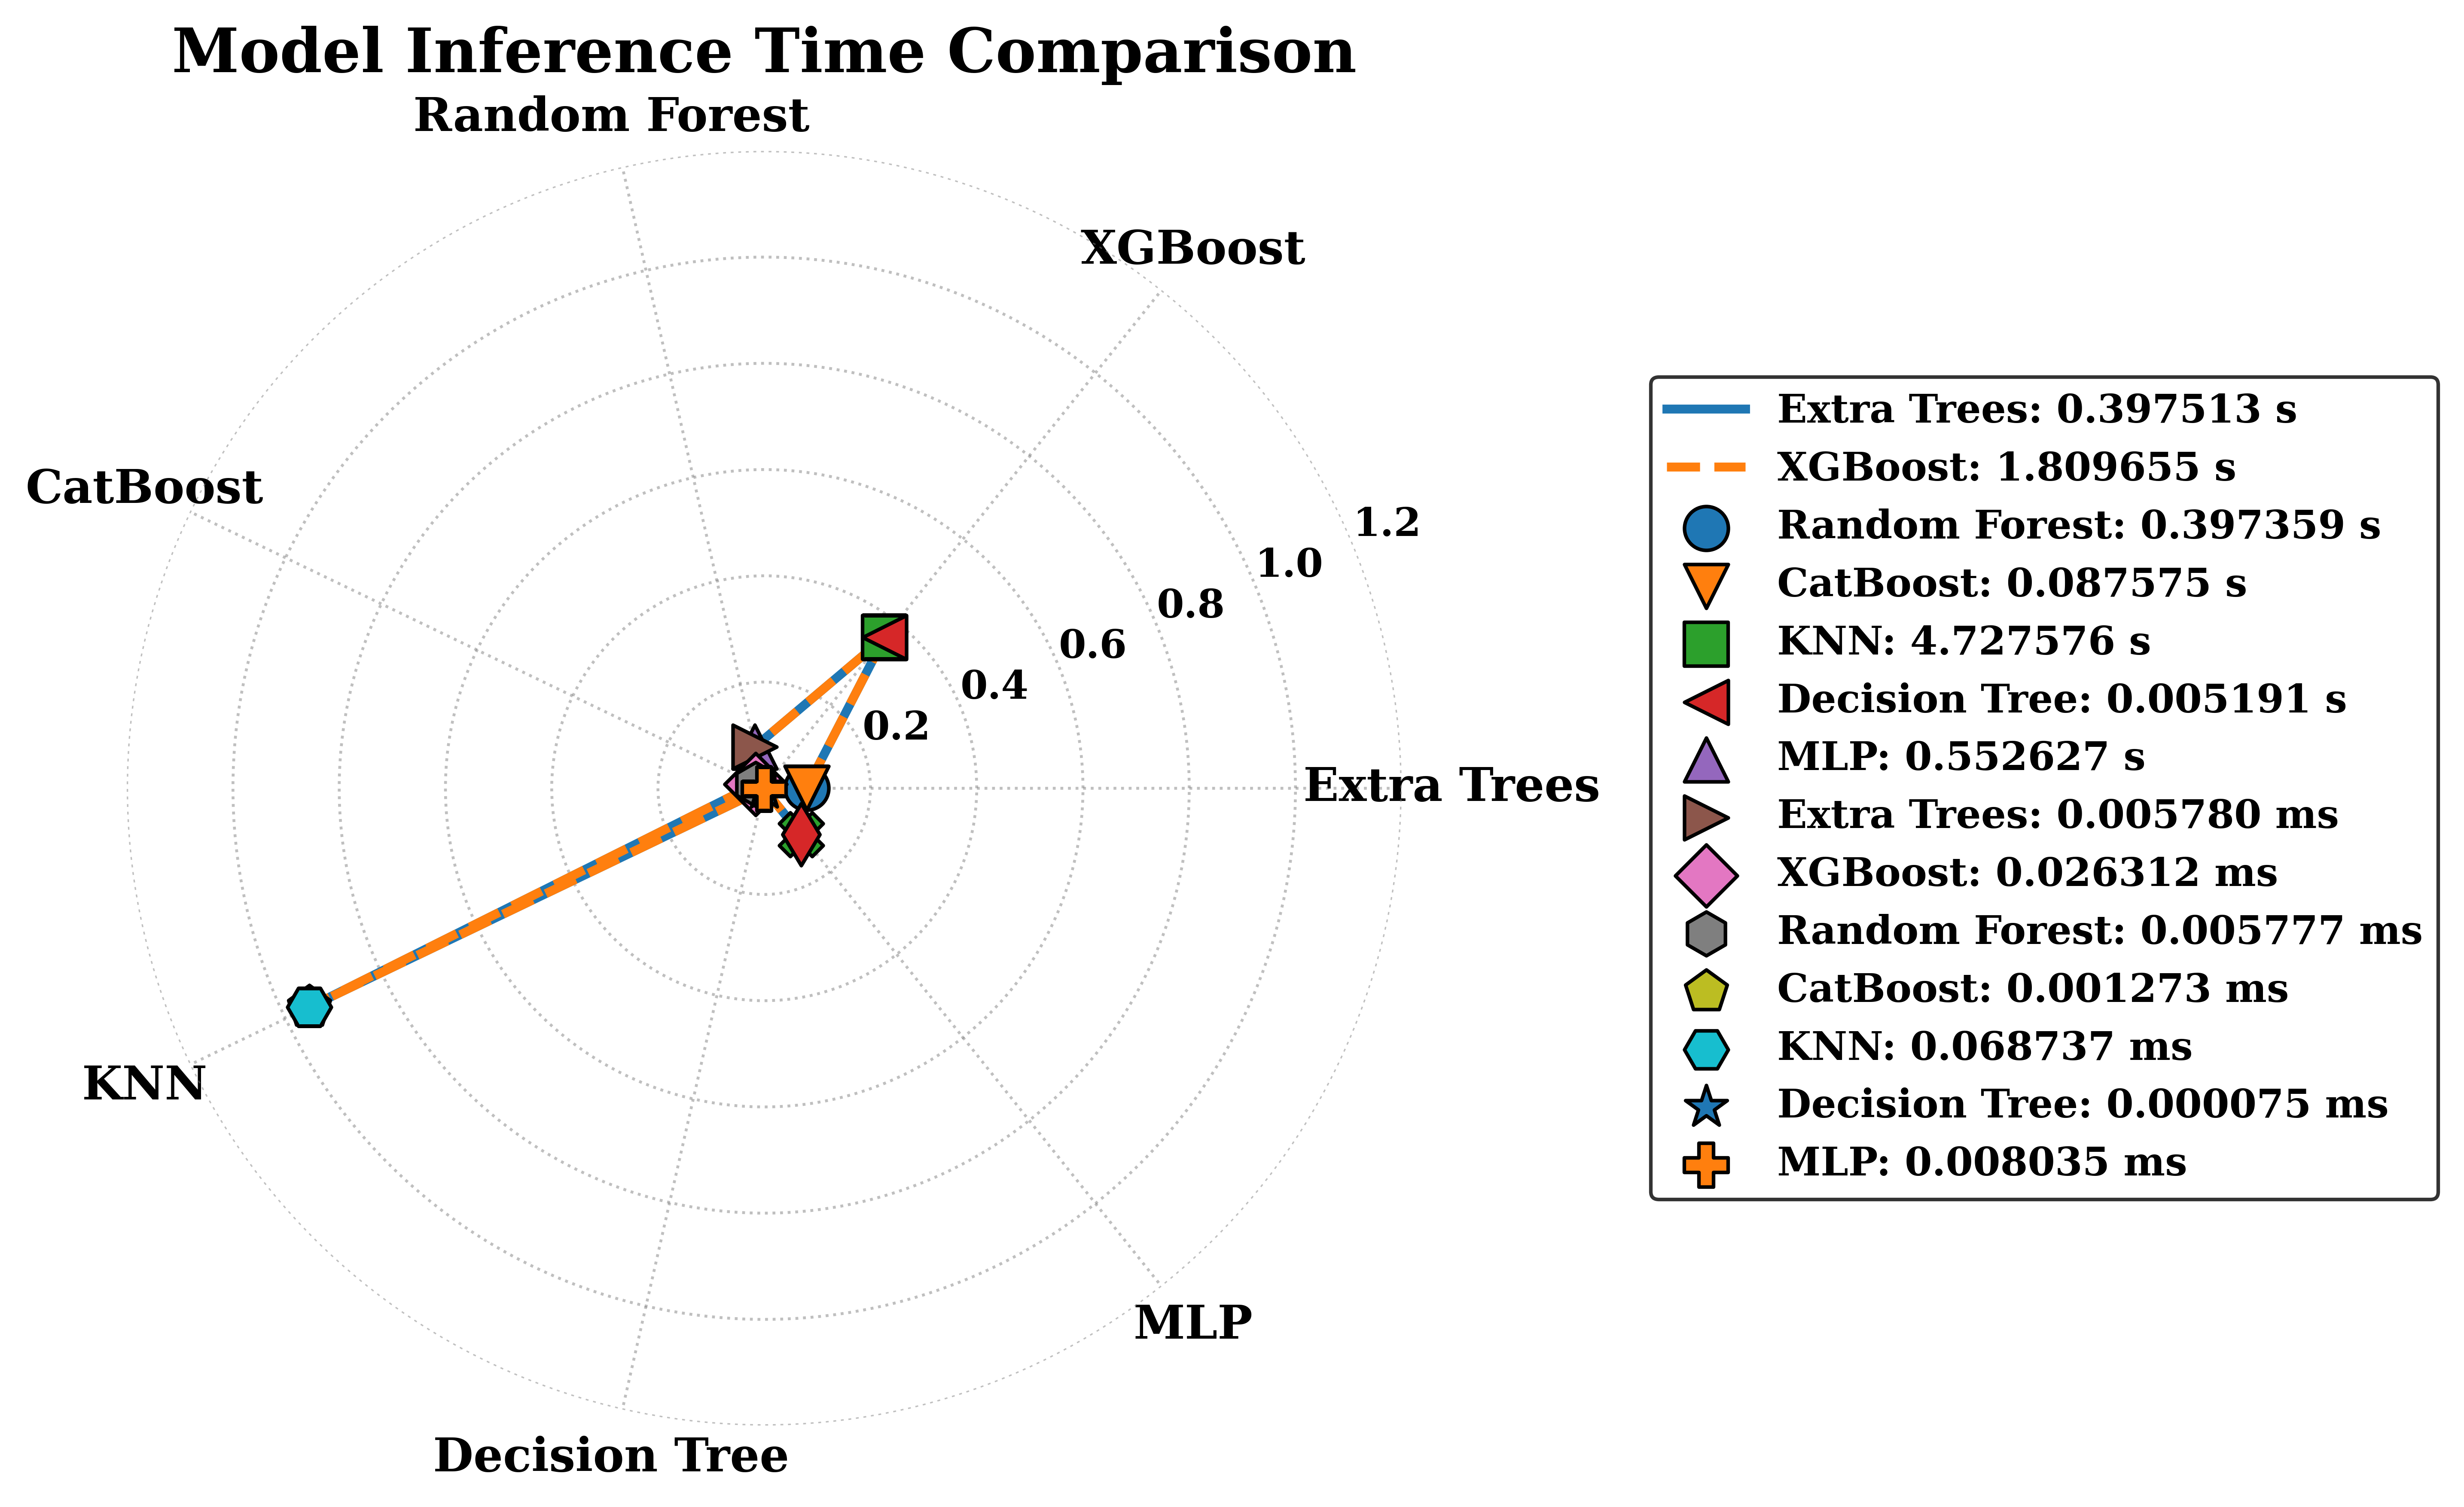

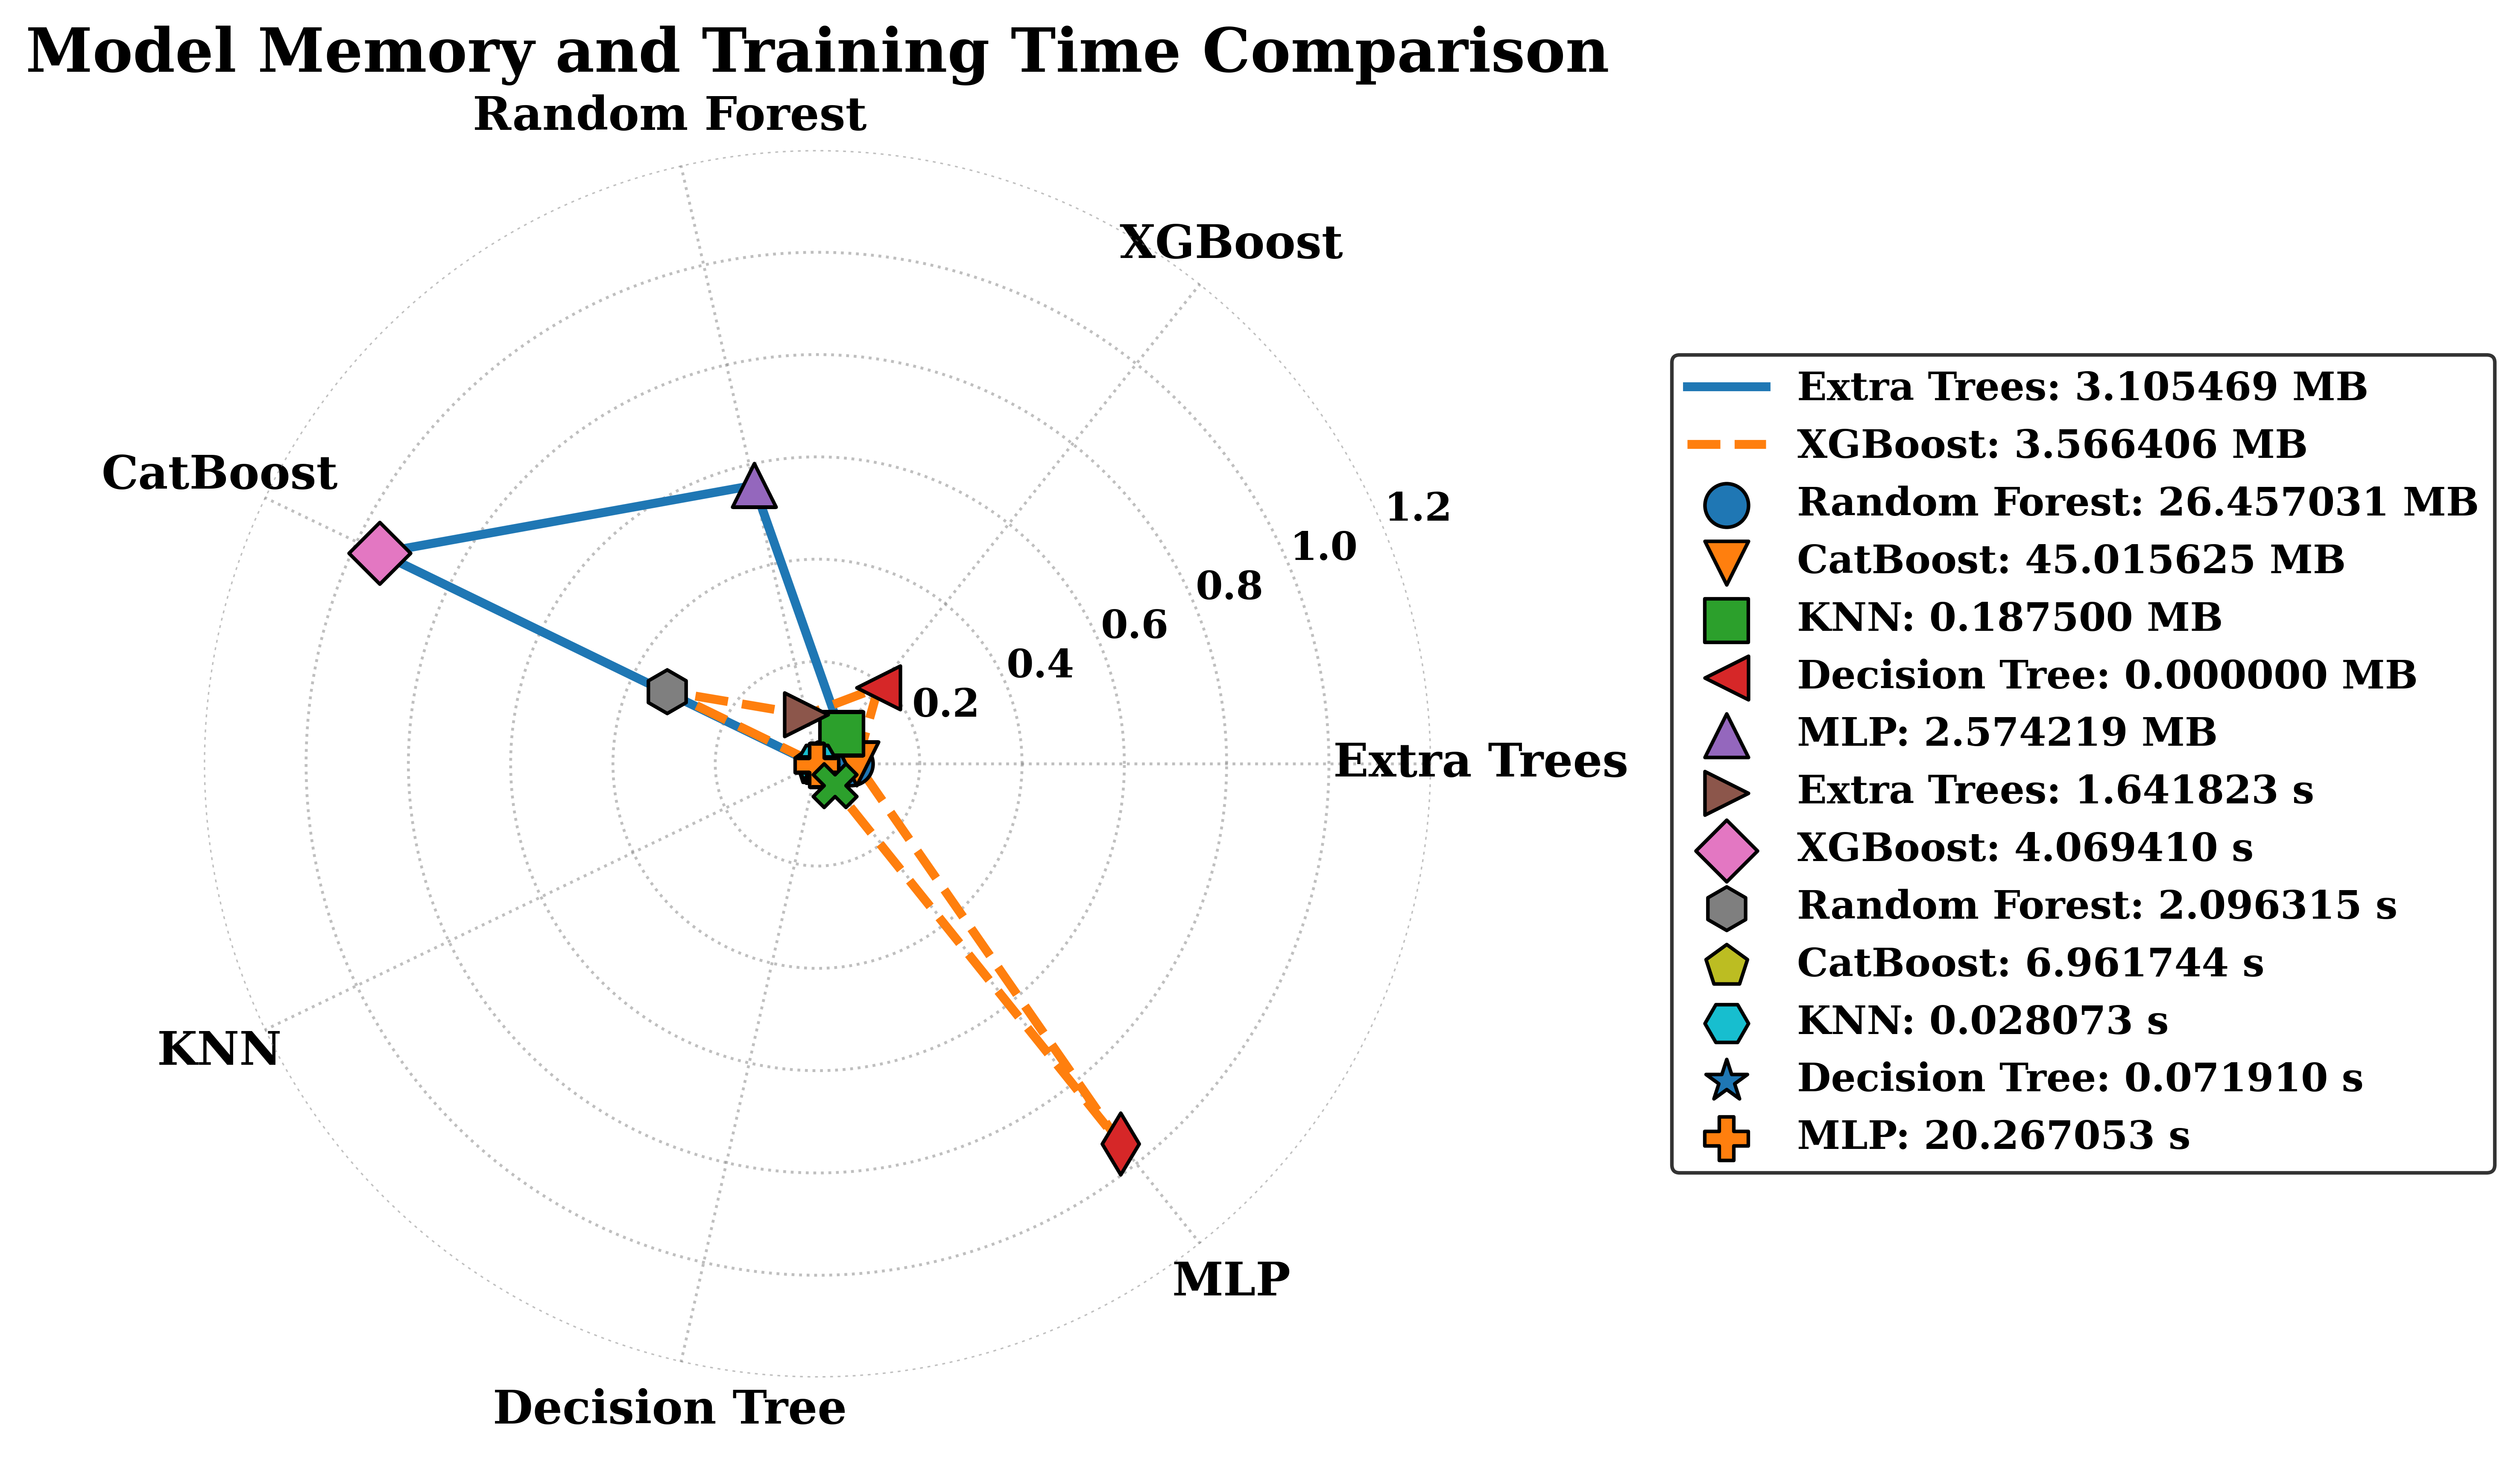

In [ ]:
import matplotlib.pyplot as plt
from math import pi


# Exact values 
models = [
    "Extra Trees", "XGBoost", "Random Forest",
    "CatBoost", "KNN", "Decision Tree", "MLP"
]

# Inference metrics
test_inference_time_s = [0.397513, 1.809655, 0.397359, 0.087575, 4.727576, 0.005191, 0.552627]
per_sample_test_ms   = [0.005780, 0.026312, 0.005777, 0.001273, 0.068737, 0.000075, 0.008035]

# Resource/computation metrics
memory_usage_mb = [3.105469, 3.566406, 26.457031, 45.015625, 0.187500, 0.000000, 2.574219]
training_time_s = [1.641823, 4.069410, 2.096315, 6.961744, 0.028073, 0.071910, 20.267053]

# Normalize for radar plotting
def normalize(data, pad=0.05):
    max_val = max(data) if max(data) != 0 else 1
    return [v / max_val * (1 - pad) for v in data]


# Radar chart function
def radar_chart(models, vals1, vals2, values_real1, values_real2,
                title, label1, label2, unit1, unit2,
                markers1, markers2, save_name=None):
    num_vars = len(models)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]

    vals1_closed = vals1 + vals1[:1]
    vals2_closed = vals2 + vals2[:1]

    plt.figure(figsize=(10, 10), facecolor="white", dpi=600)
    ax = plt.subplot(111, polar=True)
    ax.set_facecolor("white")

    # Grid and style
    ax.spines["polar"].set_visible(False)
    ax.grid(color="gray", linestyle="dotted", linewidth=0.8, alpha=0.5)

    plt.xticks(
        angles[:-1], models,
        color="black", fontsize=13, fontweight="bold"
    )
    plt.yticks(
        fontsize=11, fontweight="bold", color="black"
    )
    plt.ylim(0, 1.2)

    # Plot lines
    ax.plot(angles, vals1_closed, linewidth=2.5, linestyle="solid", label=label1)
    ax.plot(angles, vals2_closed, linewidth=2.5, linestyle="dashed", label=label2)

    # Plot markers
    for i in range(num_vars):
        ax.scatter(
            angles[i], vals1[i],
            marker=markers1[i % len(markers1)],
            s=150, edgecolors="black", zorder=5
        )
        ax.scatter(
            angles[i], vals2[i],
            marker=markers2[i % len(markers2)],
            s=150, edgecolors="black", zorder=5
        )

    # Legend values with units
    legend_entries_1 = [f"{models[i]}: {values_real1[i]:.6f} {unit1}" for i in range(num_vars)]
    legend_entries_2 = [f"{models[i]}: {values_real2[i]:.6f} {unit2}" for i in range(num_vars)]

    legend = plt.legend(
        legend_entries_1 + legend_entries_2,
        loc="center left",
        bbox_to_anchor=(1.18, 0.5),
        fontsize=11,
        facecolor="white",
        edgecolor="black",
        frameon=True
    )

    for text in legend.get_texts():
        text.set_fontweight("bold")

    plt.title(title, size=17, color="black", pad=22, fontweight="bold")
    plt.tight_layout()

    if save_name:
        plt.savefig(save_name, dpi=600, bbox_inches="tight")

    plt.show()


# Normalize data
infer_norm = normalize(test_inference_time_s)
sample_norm = normalize(per_sample_test_ms)
memory_norm = normalize(memory_usage_mb)
train_norm = normalize(training_time_s)


# Markers
markers_line1 = ["o", "s", "^", "D", "p", "*", "X"]
markers_line2 = ["v", "<", ">", "h", "H", "P", "d"]


# Chart 1: Inference comparison
radar_chart(
    models=models,
    vals1=infer_norm,
    vals2=sample_norm,
    values_real1=test_inference_time_s,
    values_real2=per_sample_test_ms,
    title="Model Inference Time Comparison",
    label1="Test Inference Time",
    label2="Per-Sample Test Time",
    unit1="s",
    unit2="ms",
    markers1=markers_line1,
    markers2=markers_line2,
    save_name="model_inference_time_comparison.png"
)


# Chart 2: Memory and training time comparison
radar_chart(
    models=models,
    vals1=memory_norm,
    vals2=train_norm,
    values_real1=memory_usage_mb,
    values_real2=training_time_s,
    title="Model Memory and Training Time Comparison",
    label1="Memory Usage",
    label2="Training Time",
    unit1="MB",
    unit2="s",
    markers1=markers_line1,
    markers2=markers_line2,
    save_name="model_memory_training_comparison.png"
)